<a href="https://colab.research.google.com/github/cecpiloneo/Dataset/blob/main/Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# 1. Load the processed dataset
file_path = 'https://raw.githubusercontent.com/cecpiloneo/Dataset/refs/heads/main/philippine_earthquakes_processed-2.csv'
df = pd.read_csv(file_path)
# 2. Define Features and Target
# We use the scaled features and the risk_encoded target
features = ['latitude_mm', 'longitude_mm']
target = 'risk_encoded'

X = df[features]
y = df[target]

# 3. Split the data (80% training, 20% testing)
# 'stratify=y' ensures the rare "Very High" cases are split between train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize and Train k-NN (using k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Get Predictions
y_pred = knn.predict(X_test)

# 6. Print Evaluation Metrics
print("--- k-NN Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- k-NN Model Evaluation Metrics ---
Accuracy:  0.6980
Precision: 0.6656
Recall:    0.6980
F1-Score:  0.6732

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.60      0.57      0.58      1257
           1       0.74      0.83      0.79      2850
           2       0.28      0.04      0.08       345
           3       0.00      0.00      0.00         2

    accuracy                           0.70      4454
   macro avg       0.41      0.36      0.36      4454
weighted avg       0.67      0.70      0.67      4454



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

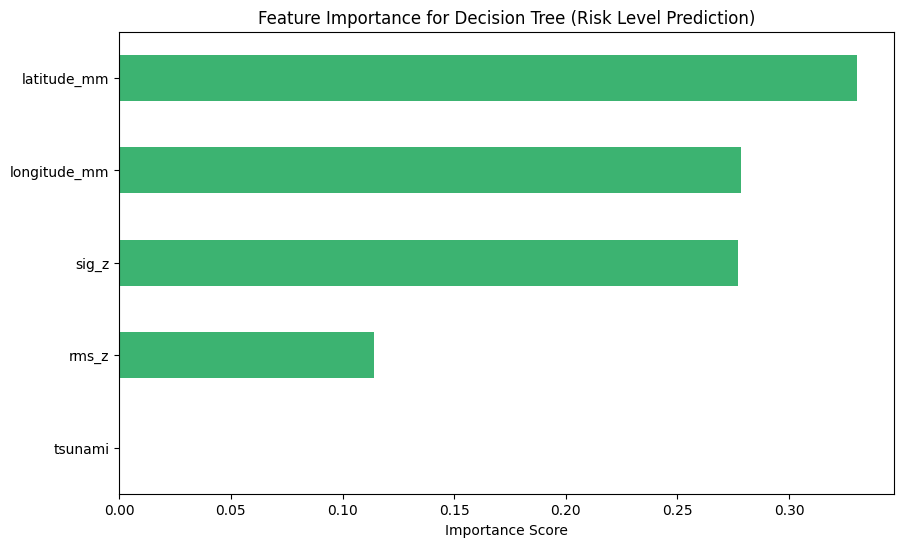

--- Decision Tree Classifier Evaluation Metrics ---
Accuracy:  0.7611
Precision: 0.7626
Recall:    0.7611
F1-Score:  0.7618

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.61      0.63      0.62      1257
           1       0.82      0.81      0.81      2850
           2       0.83      0.86      0.84       345
           3       0.00      0.00      0.00         2

    accuracy                           0.76      4454
   macro avg       0.57      0.57      0.57      4454
weighted avg       0.76      0.76      0.76      4454



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# 1. Load the processed dataset
file_path = 'https://raw.githubusercontent.com/cecpiloneo/Dataset/refs/heads/main/philippine_earthquakes_processed-2.csv'
df = pd.read_csv(file_path)
features = ['latitude_mm', 'longitude_mm', 'rms_z', 'tsunami', 'sig_z']
target = 'risk_encoded'

X = df[features]
y = df[target]

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize and Train Decision Tree
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# 5. Get Predictions
y_pred = dtc.predict(X_test)

# --- NEW: FEATURE IMPORTANCE SECTION ---
importances = dtc.feature_importances_
dt_importances = pd.Series(importances, index=features).sort_values(ascending=True)

# Visualize the importance
plt.figure(figsize=(10, 6))
dt_importances.plot(kind='barh', color='mediumseagreen')
plt.title("Feature Importance for Decision Tree (Risk Level Prediction)")
plt.xlabel("Importance Score")
plt.show()

# 6. Print Evaluation Metrics
print("--- Decision Tree Classifier Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

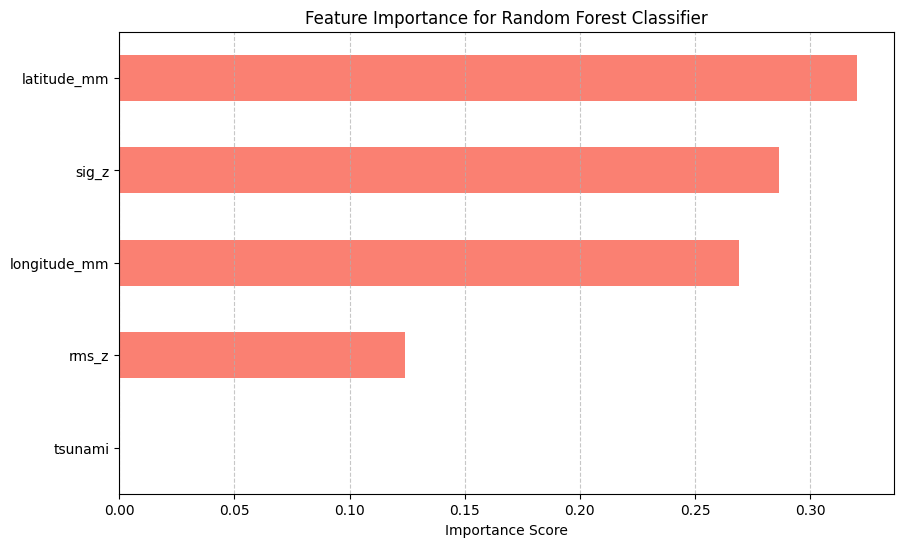

--- Random Forest Classifier Evaluation Metrics ---
Accuracy:  0.8260
Precision: 0.8224
Recall:    0.8260
F1-Score:  0.8230

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.66      0.70      1257
           1       0.85      0.88      0.87      2850
           2       0.84      0.94      0.89       345
           3       0.00      0.00      0.00         2

    accuracy                           0.83      4454
   macro avg       0.61      0.62      0.62      4454
weighted avg       0.82      0.83      0.82      4454


--- Feature Importances ---
latitude_mm     0.320418
sig_z           0.286526
longitude_mm    0.268867
rms_z           0.124190
tsunami         0.000000
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# 1. Load the processed dataset
file_path = 'https://raw.githubusercontent.com/cecpiloneo/Dataset/refs/heads/main/philippine_earthquakes_processed-2.csv'
df = pd.read_csv(file_path)
# 2. Define Features and Target
# You can add 'rms_z', 'tsunami', and 'sig_z' here if you want to include them!
features = ['latitude_mm', 'longitude_mm','sig_z','tsunami','rms_z']
target = 'risk_encoded'

X = df[features]
y = df[target]

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialize and Train Random Forest
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

# 5. Get Predictions
y_pred = rfc.predict(X_test)

# --- FEATURE IMPORTANCE SECTION ---
# Extract importance from Random Forest
importances = rfc.feature_importances_
rf_importances = pd.Series(importances, index=features).sort_values(ascending=True)

# Visualize the importance
plt.figure(figsize=(10, 6))
rf_importances.plot(kind='barh', color='salmon')
plt.title("Feature Importance for Random Forest Classifier")
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 6. Print Evaluation Metrics
print("--- Random Forest Classifier Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# Print sorted importances for your report
print("\n--- Feature Importances ---")
print(rf_importances.sort_values(ascending=False))